In [16]:
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv("RAG_system/data/LF_Jobs.csv")
df.head()

,ID,Job Category,Job Title,Company Name,Publication Date,Job Location,Job Level,Tags,Job Description
0,LF0001,Data and Analytics,"DIR, Equities Quant",Merrill,2025-07-28T23:00:54Z,"New York, NY",Mid Level,NaN,<p><b>Job Description:</b><br><br>At Bank of A...
1,LF0002,Data and Analytics,Lead Administrator - L1,Wipro,2025-06-15T23:43:28Z,"Hyderabad, India",Senior Level,NaN,"<p>Wipro Limited (NYSE: WIT, BSE: 507685, NSE:..."
2,LF0003,Data and Analytics,Principal DEX Solutions Architect,Eaton,2025-07-30T11:38:27Z,"Chicago, IL",Senior Level,NaN,<p>Eaton's Digital Employee Experience (DEX) t...
3,LF0004,Data and Analytics,Retail Sales Supervisor- Melrose Studio,Soho House,2025-07-29T23:31:48Z,"West Hollywood, CA",Senior Level,NaN,<p><strong>The Role…</strong></p>\n\n<p>We are...
4,LF0005,Data and Analytics,CAT Program Specialist,Royal Bank of Canada,2024-05-03T11:42:19Z,"Minneapolis, MN",Mid Level,NaN,<p><b>Job Summary</b><br><br><b> Job Descripti...


In [ ]:
print("Number of Null cells:")
print(df.isnull().sum())

Number of Null cells:
ID                    0
Job Category          0
Job Title             0
Company Name          0
Publication Date      0
Job Location          9
Job Level             0
Tags                880
Job Description       0
dtype: int64


In [9]:
print("Number of duplicated data:")
print(df.duplicated().sum())


Number of duplicated data:
0


In [13]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Shape: (1000, 13)

Columns:
['ID', 'Job Category', 'Job Title', 'Company Name', 'Publication Date', 'Job Location', 'Job Level', 'Tags', 'Job Description', 'desc_char_length', 'has_bold_tags', 'has_tags', 'quality_flag']

Data Types:
ID                                  str
Job Category                        str
Job Title                           str
Company Name                        str
Publication Date    datetime64[us, UTC]
Job Location                        str
Job Level                           str
Tags                                str
Job Description                     str
desc_char_length                  int64
has_bold_tags                      bool
has_tags                           bool
quality_flag                        str
dtype: object


In [14]:
categorical_cols = [
    "Job Category",
    "Company Name",
    "Job Level",
    "Job Location"
]

for col in categorical_cols:
    print(f"\n{'='*60}")
    print(f"{col}")
    print(f"{'='*60}")

    print("Unique values:", df[col].nunique())
    print(df[col].value_counts().head(20))


Job Category
Unique values: 7
Job Category
Data and Analytics           166
Software Engineering         166
Design and UX                166
Sales                        166
Project Management           166
Advertising and Marketing    166
General                        4
Name: count, dtype: int64

Company Name
Unique values: 145
Company Name
Meta                     66
JPMorgan Chase           66
CVS Health               60
EPAM Systems             57
Wipro                    52
TikTok                   51
Walmart                  42
Northrop Grumman         28
IBM                      27
Schneider Electric       20
Mastercard               18
Salesforce               16
Kohl's                   16
Kyndryl                  14
GE Vernova               13
Palo Alto Networks       13
Leidos                   13
Spectrum                 13
ELC Beauty               12
Power Home Remodeling    12
Name: count, dtype: int64

Job Level
Unique values: 4
Job Level
Senior Level    610
Mid Level

In [17]:
df["desc_char_length"] = df["Job Description"].astype(str).apply(len)

print("\nDescription Length Stats")
print(df["desc_char_length"].describe())


Description Length Stats
count     1000.000000
mean      5754.571000
std       2004.732011
min        727.000000
25%       4417.000000
50%       5616.000000
75%       7052.500000
max      17051.000000
Name: desc_char_length, dtype: float64


In [21]:
# Extremely short descriptions
short_desc = df[df["desc_char_length"] < 500]

print("\nVery Short Descriptions (<500 chars):")
print(short_desc[["ID", "Job Title", "Company Name", "desc_char_length"]])


print("--"*20)
# Extremely long descriptions
long_desc = df[df["desc_char_length"] > 15000]

print("\nVery Long Descriptions (>15000 chars):")
print(long_desc[["ID", "Job Title", "Company Name", "desc_char_length"]])


Very Short Descriptions (<500 chars):
Empty DataFrame
Columns: [ID, Job Title, Company Name, desc_char_length]
Index: []
----------------------------------------

Very Long Descriptions (>15000 chars):
         ID                                          Job Title Company Name  \
858  LF0859  Senior Manager, Compliance Governance & Operat...      TD Bank   

     desc_char_length  
858             17051  


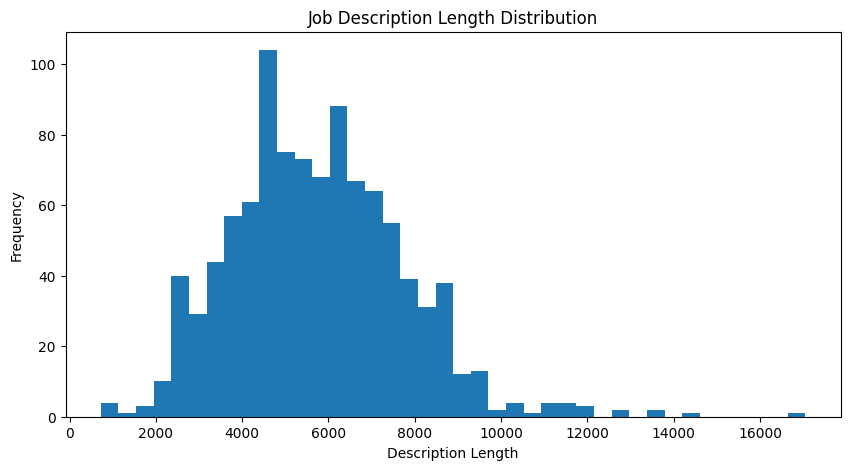

In [19]:

# Histogram
plt.figure(figsize=(10, 5))
plt.hist(df["desc_char_length"], bins=40)
plt.xlabel("Description Length")
plt.ylabel("Frequency")
plt.title("Job Description Length Distribution")
plt.show()

In [24]:
# Sample rows with HTML sections
sample_html = df[df["has_bold_tags"]].sample(5)

for idx, row in sample_html.iterrows():
    print("\n" + "="*80)
    print("JOB TITLE:", row["Job Title"])
    print("="*80)
    print(row["Job Description"][:1500])


JOB TITLE: Research Scientist, Computer Vision (PhD)
<p>Meta is seeking Research Scientists to join its Fundamental AI Research (FAIR) organization to work on making significant advances in AI. We are seeking talented researchers with experience in vision-language models and general AI to join the team to investigate how to build contextually aware AI that will be the foundation for a new paradigm in how we interact and use computers. The chosen candidate will work with a highly interdisciplinary team of scientists, engineers, and cross-functional partners with a broad range of experiences, perspectives, approaches, and backgrounds, and access cutting-edge technology, resources, and research facilities. <br><br><b>Research Scientist, Computer Vision (PhD) Responsibilities: <br></b><ul><li>Develop algorithms based on state-of-the-art machine learning and neural network methodologies</li><li>Define, build and benchmark new capabilities needed for the next generation of AI</li><li>Work w

In [33]:
df["has_section_tags"] = (
    df["Job Description"]
    .astype(str)
    .str.contains(
        r"<b>|<strong>|<h1>|<h2>|<h3>",
        case=False,
        regex=True
    )
)

print("\nRows With Semantic Section Tags:")
print(df["has_section_tags"].value_counts())

percentage = df["has_section_tags"].mean() * 100

print(f"\nPercentage with semantic structure: {percentage:.2f}%")


Rows With Semantic Section Tags:
has_section_tags
True     958
False     42
Name: count, dtype: int64

Percentage with semantic structure: 95.80%


In [32]:
structured_samples = df[
    df["has_section_tags"]
].head(3)

for _, row in structured_samples.iterrows():

    print("\n" + "=" * 80)
    print("JOB TITLE:", row["Job Title"])
    print("=" * 80)

    print(row["Job Description"][:1200])


JOB TITLE: DIR, Equities Quant
<p><b>Job Description:</b><br><br>At Bank of America, we are guided by a common purpose to help make financial lives better through the power of every connection. We do this by driving Responsible Growth and delivering for our clients, teammates, communities and shareholders every day.<br><br>Being a Great Place to Work is core to how we drive Responsible Growth. This includes our commitment to being an inclusive workplace, attracting and developing exceptional talent, supporting our teammates' physical, emotional, and financial wellness, recognizing and rewarding performance, and how we make an impact in the communities we serve.<br><br>Bank of America is committed to an in-office culture with specific requirements for office-based attendance and which allows for an appropriate level of flexibility for our teammates and businesses based on role-specific considerations.<br><br>At Bank of America, you can build a successful career with opportunities to le

In [31]:
metadata_cols = [
    "Job Category",
    "Job Level",
    "Job Location",
    "Company Name"
]

for col in metadata_cols:

    print("\n" + "=" * 60)
    print(col)
    print("=" * 60)

    print("Unique Values:", df[col].nunique())

    print(df[col].value_counts().head(10))


Job Category
Unique Values: 7
Job Category
Data and Analytics           166
Software Engineering         166
Design and UX                166
Sales                        166
Project Management           166
Advertising and Marketing    166
General                        4
Name: count, dtype: int64

Job Level
Unique Values: 4
Job Level
Senior Level    610
Mid Level       349
Internship       24
Entry Level      17
Name: count, dtype: int64

Job Location
Unique Values: 489
Job Location
New York, NY              35
Bangalore, India          33
Flexible / Remote         24
Pune, India               22
Singapore                 21
London, United Kingdom    20
Hyderabad, India          15
Menlo Park, CA            15
Tokyo, Japan              15
Los Angeles, CA           14
Name: count, dtype: int64

Company Name
Unique Values: 145
Company Name
Meta                  66
JPMorgan Chase        66
CVS Health            60
EPAM Systems          57
Wipro                 52
TikTok                

In [30]:
df["has_tags"] = (
    df["Tags"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
)

print("\nRows With Tags:")
print(df["has_tags"].value_counts())

print(
    f"\nTag coverage: "
    f"{df['has_tags'].mean() * 100:.2f}%"
)


Rows With Tags:
has_tags
False    880
True     120
Name: count, dtype: int64

Tag coverage: 12.00%


In [ ]:
df["Publication Date"] = pd.to_datetime(
    df["Publication Date"],
    errors="coerce"
)

print("\nPublication Date Range:")

print(
    "Min:",
    df["Publication Date"].min()
)

print(
    "Max:",
    df["Publication Date"].max()
)

print(
    "\nInvalid Dates:",
    df["Publication Date"].isna().sum())


Publication Date Range:
Min: 2023-02-01 10:05:24+00:00
Max: 2025-08-01 00:19:55+00:00

Invalid Dates: 0
